C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8549 - loss: 0.4646 - val_accuracy: 0.9034 - val_loss: 0.2969
Epoch 2/3
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.9209 - loss: 0.2391 - val_accuracy: 0.9184 - val_loss: 0.2526
Epoch 3/3
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.9353 - loss: 0.1900 - val_accuracy: 0.9308 - val_loss: 0.2116
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9293 - loss: 0.2154
Accuracy: 92.92788505554199


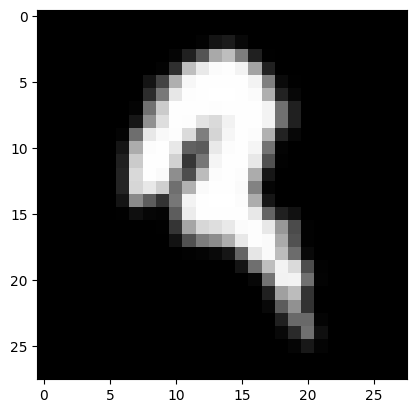

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted: A


In [1]:
# Code Example 1: Load and Preprocess Character Dataset
# Code Example 2: Neural Network for Character Recognition
# Code Example 3: Model Evaluation and Prediction
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import struct

def load_images(file):
    with open(file, 'rb') as f:
        f.read(16)
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(-1, 28, 28, 1)

def load_labels(file):
    with open(file, 'rb') as f:
        f.read(8)
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

X_train = load_images("D:/EMNIST/emnist_source_files/emnist-letters-train-images-idx3-ubyte")
y_train = load_labels("D:/EMNIST/emnist_source_files/emnist-letters-train-labels-idx1-ubyte")

X_test = load_images("D:/EMNIST/emnist_source_files/emnist-letters-test-images-idx3-ubyte")
y_test = load_labels("D:/EMNIST/emnist_source_files/emnist-letters-test-labels-idx1-ubyte")

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train - 1, 26)
y_test = to_categorical(y_test - 1, 26)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(26, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3, validation_split=0.2)

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc * 100)

labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.show()

pred = model.predict(X_test[0].reshape(1,28,28,1))
print("Predicted:", labels[np.argmax(pred)])

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\generic.py:2170: RuntimeWarning: invalid value encountered in cast
  arr = np.array(values, dtype=dtype, copy=copy)


(103598, 1003)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
[3396 3396 3419 3398 3437 3394 3385 3424 3428 3402 3438 3415 3402 3365
 3408 3430 3435 3419 3392 3436 3419 3422 3422 3437 3453 3427]


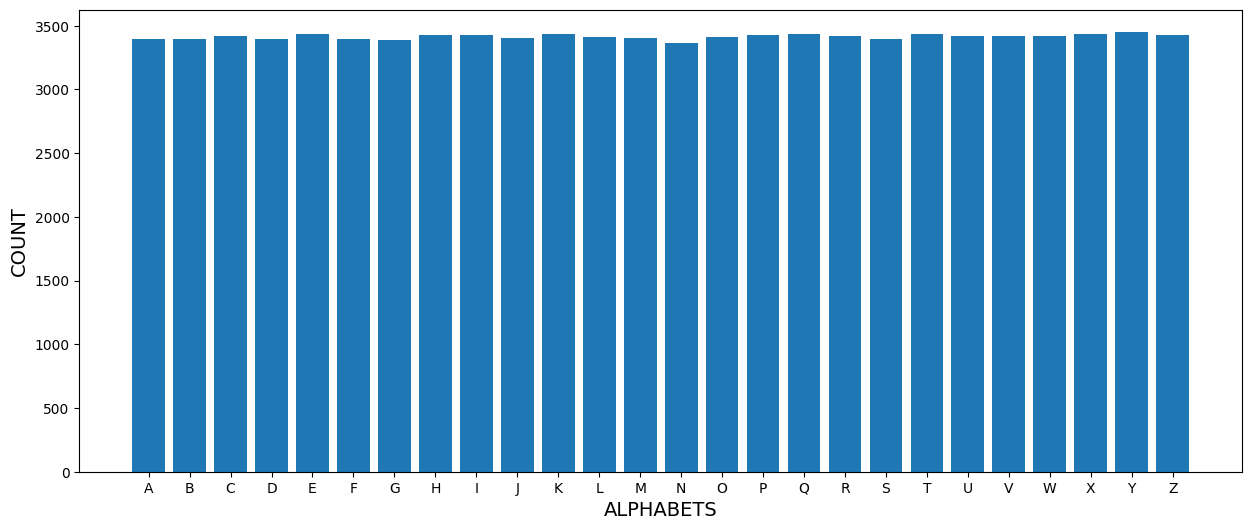

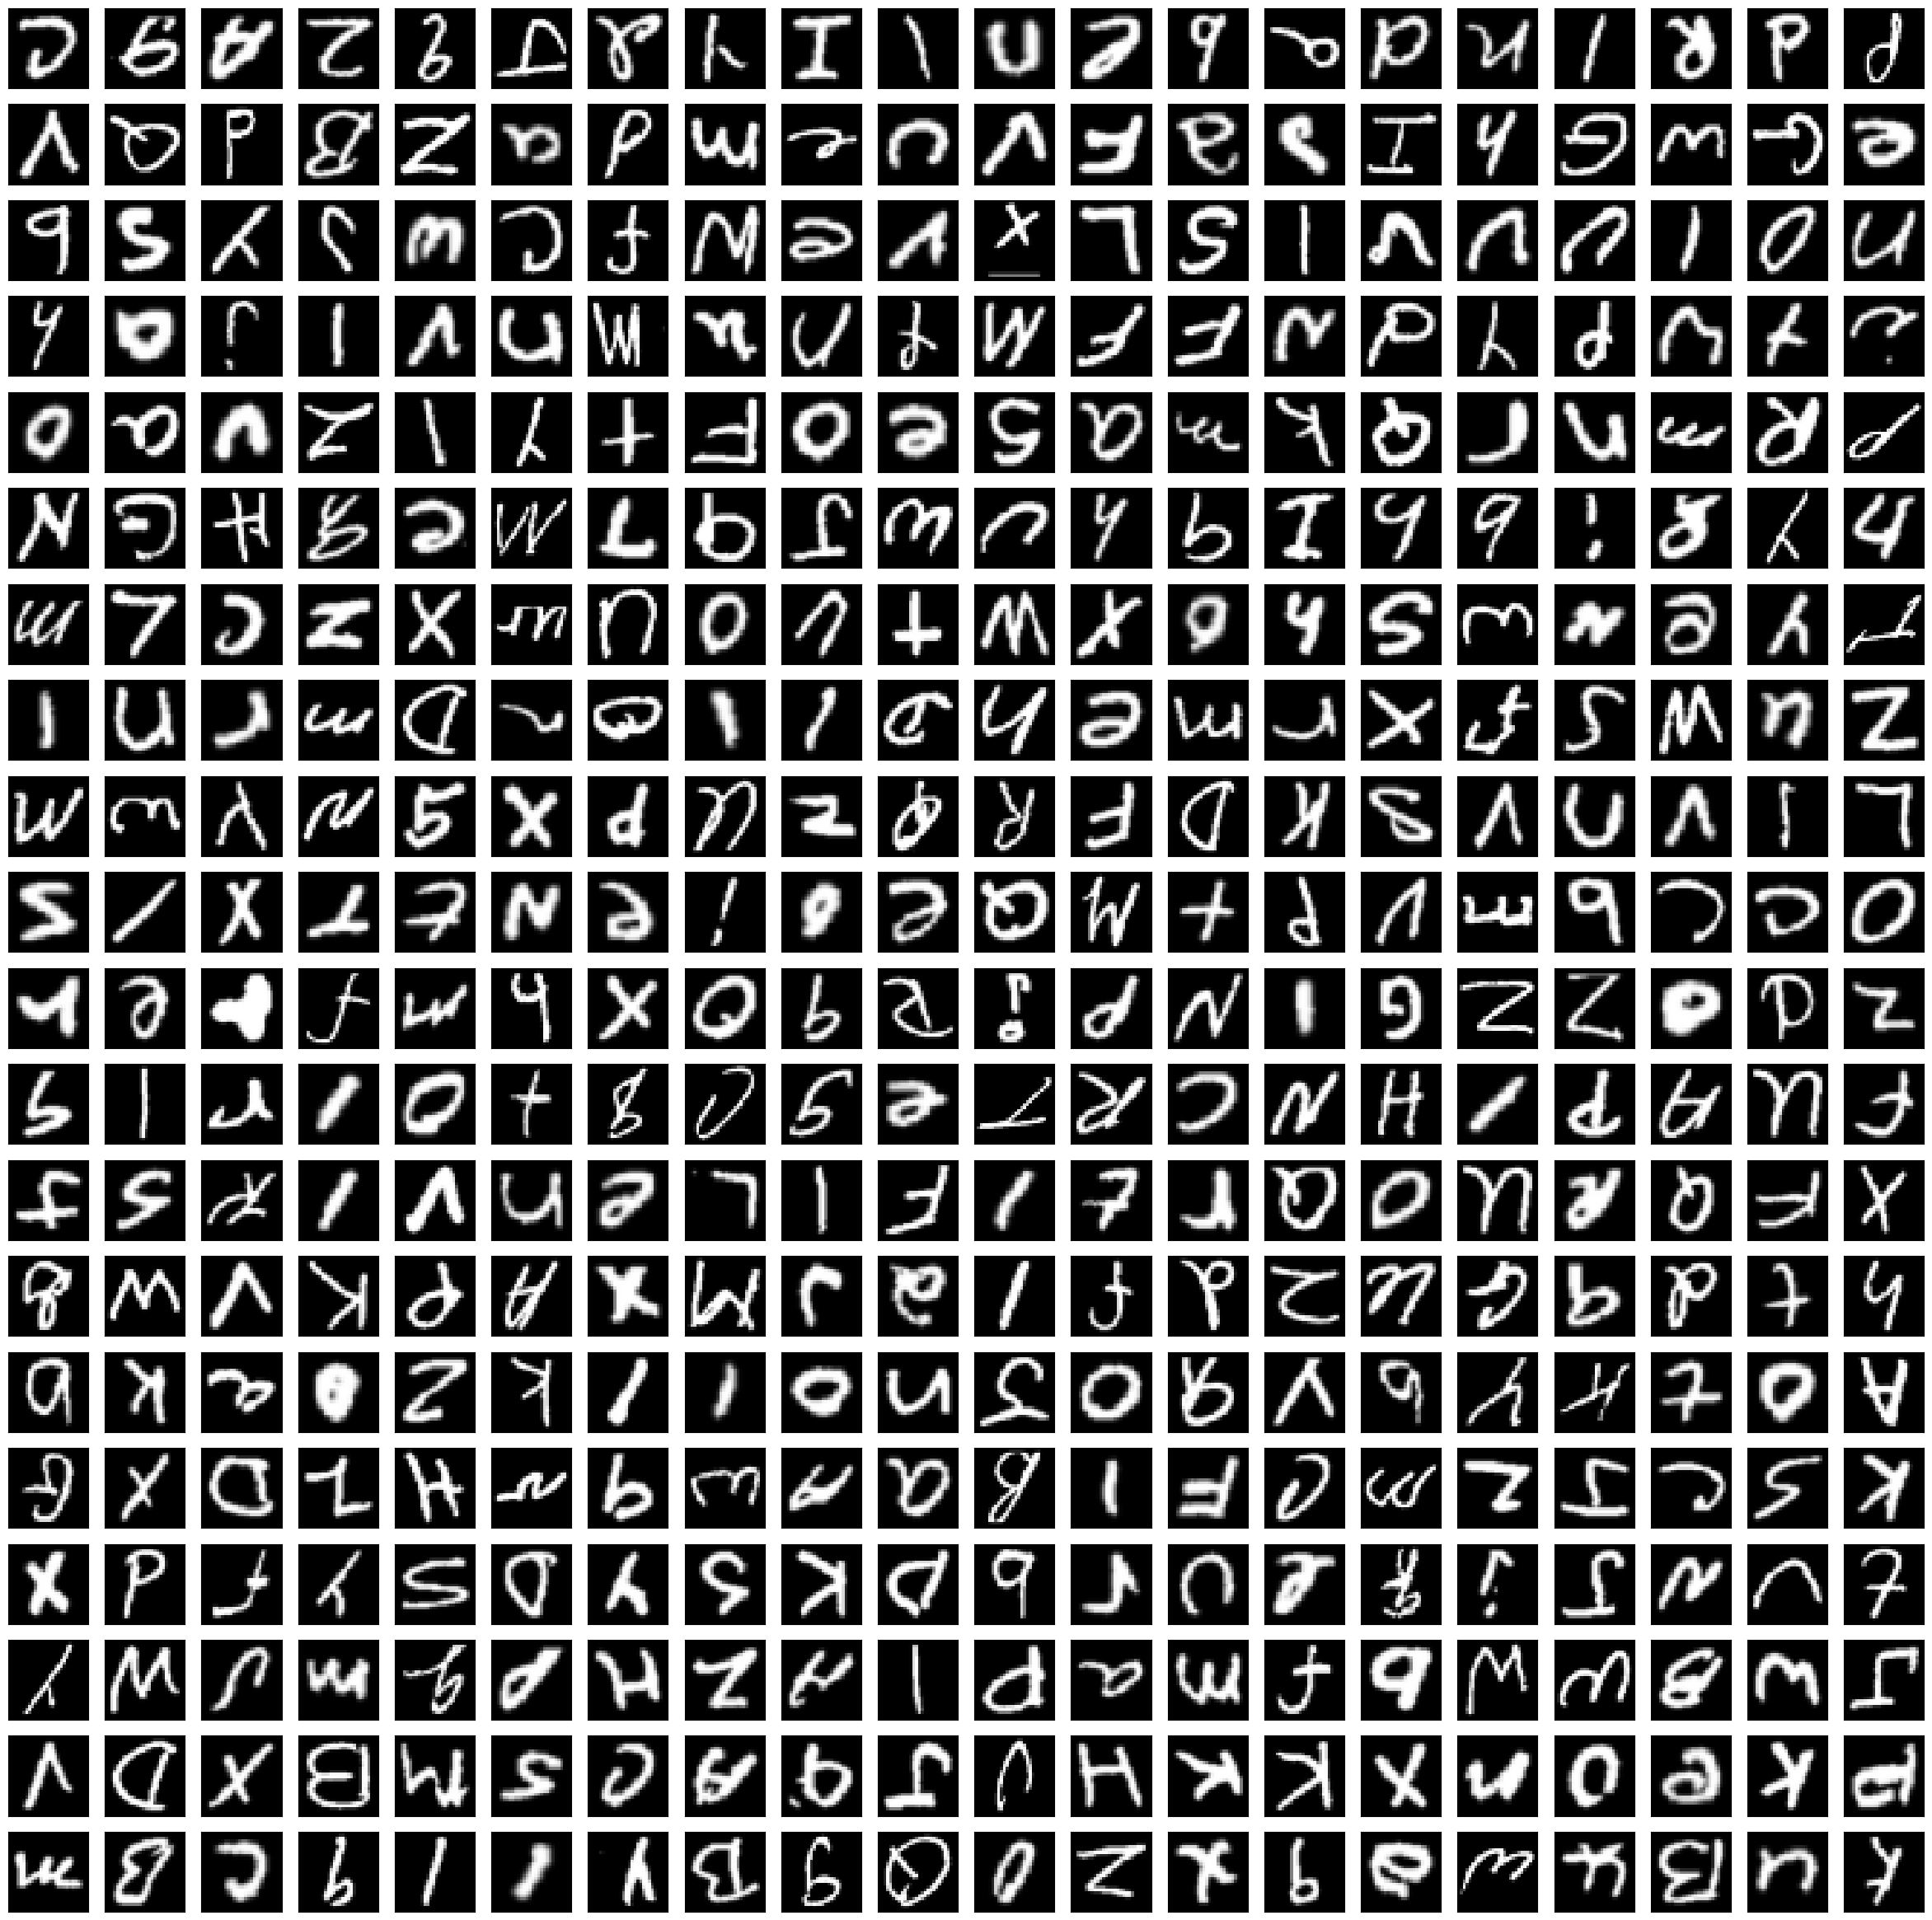

(87911, 28, 28, 1)
(888, 28, 28, 1)
(87911,)
(888,)


C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │         313,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           6,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 471,294 (1.80 MB)

 Trainable params: 471,038 (1.80 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/3
587/587 ━━━━━━━━━━━━━━━━━━━━ 238s 403ms/step - accuracy: 0.7919 - loss: 0.7101 - val_accuracy: 0.9054 - val_loss: 0.3037
Epoch 2/3
587/587 ━━━━━━━━━━━━━━━━━━━━ 246s 419ms/step - accuracy: 0.9018 - loss: 0.3154 - val_accuracy: 0.9336 - val_loss: 0.2205
Epoch 3/3
587/587 ━━━━━━━━━━━━━━━━━━━━ 254s 433ms/step - accuracy: 0.9189 - loss: 0.2505 - val_accuracy: 0.9471 - val_loss: 0.1940


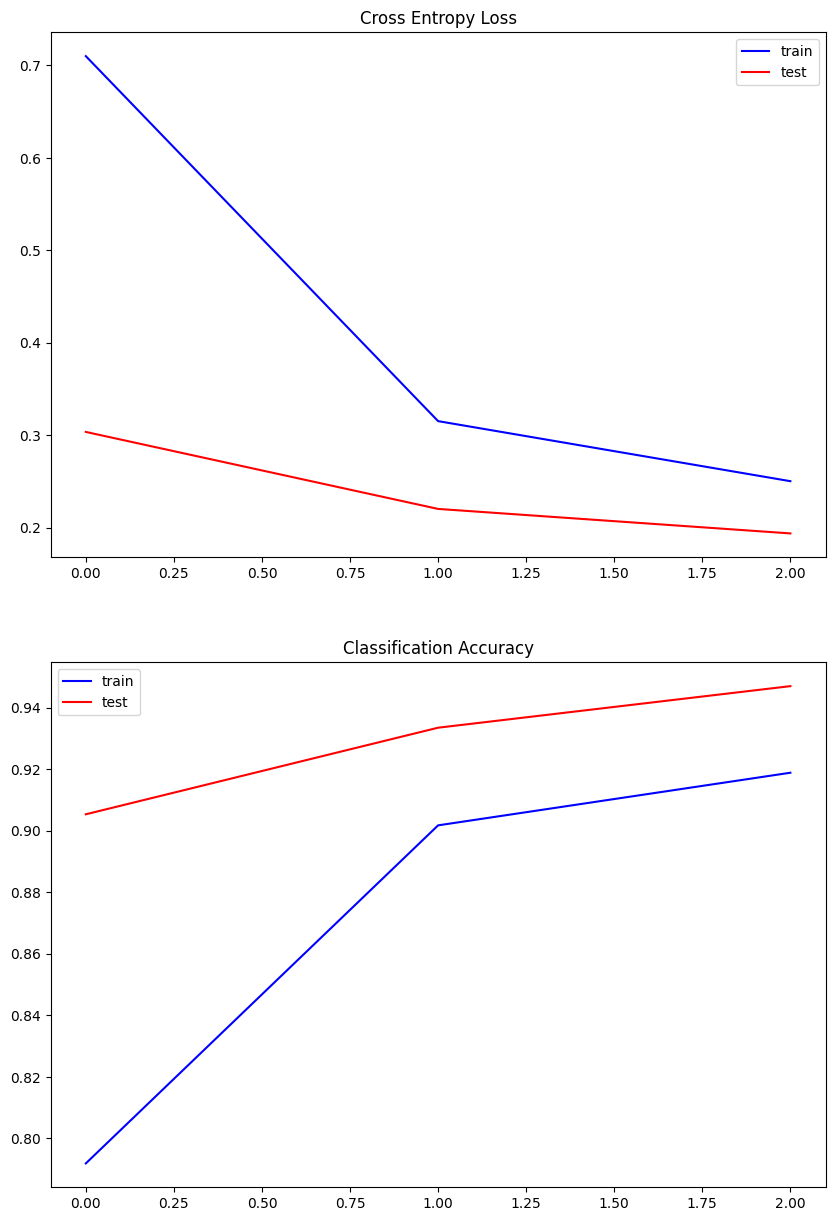

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9471 - loss: 0.1940


Test Accuracy is : 94.71
Test Loss is : 0.19


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9471 - loss: 0.1940
[0.19399066269397736, 0.9470720887184143]
Test Accuracy is : 94.71
Test Loss is : 0.19


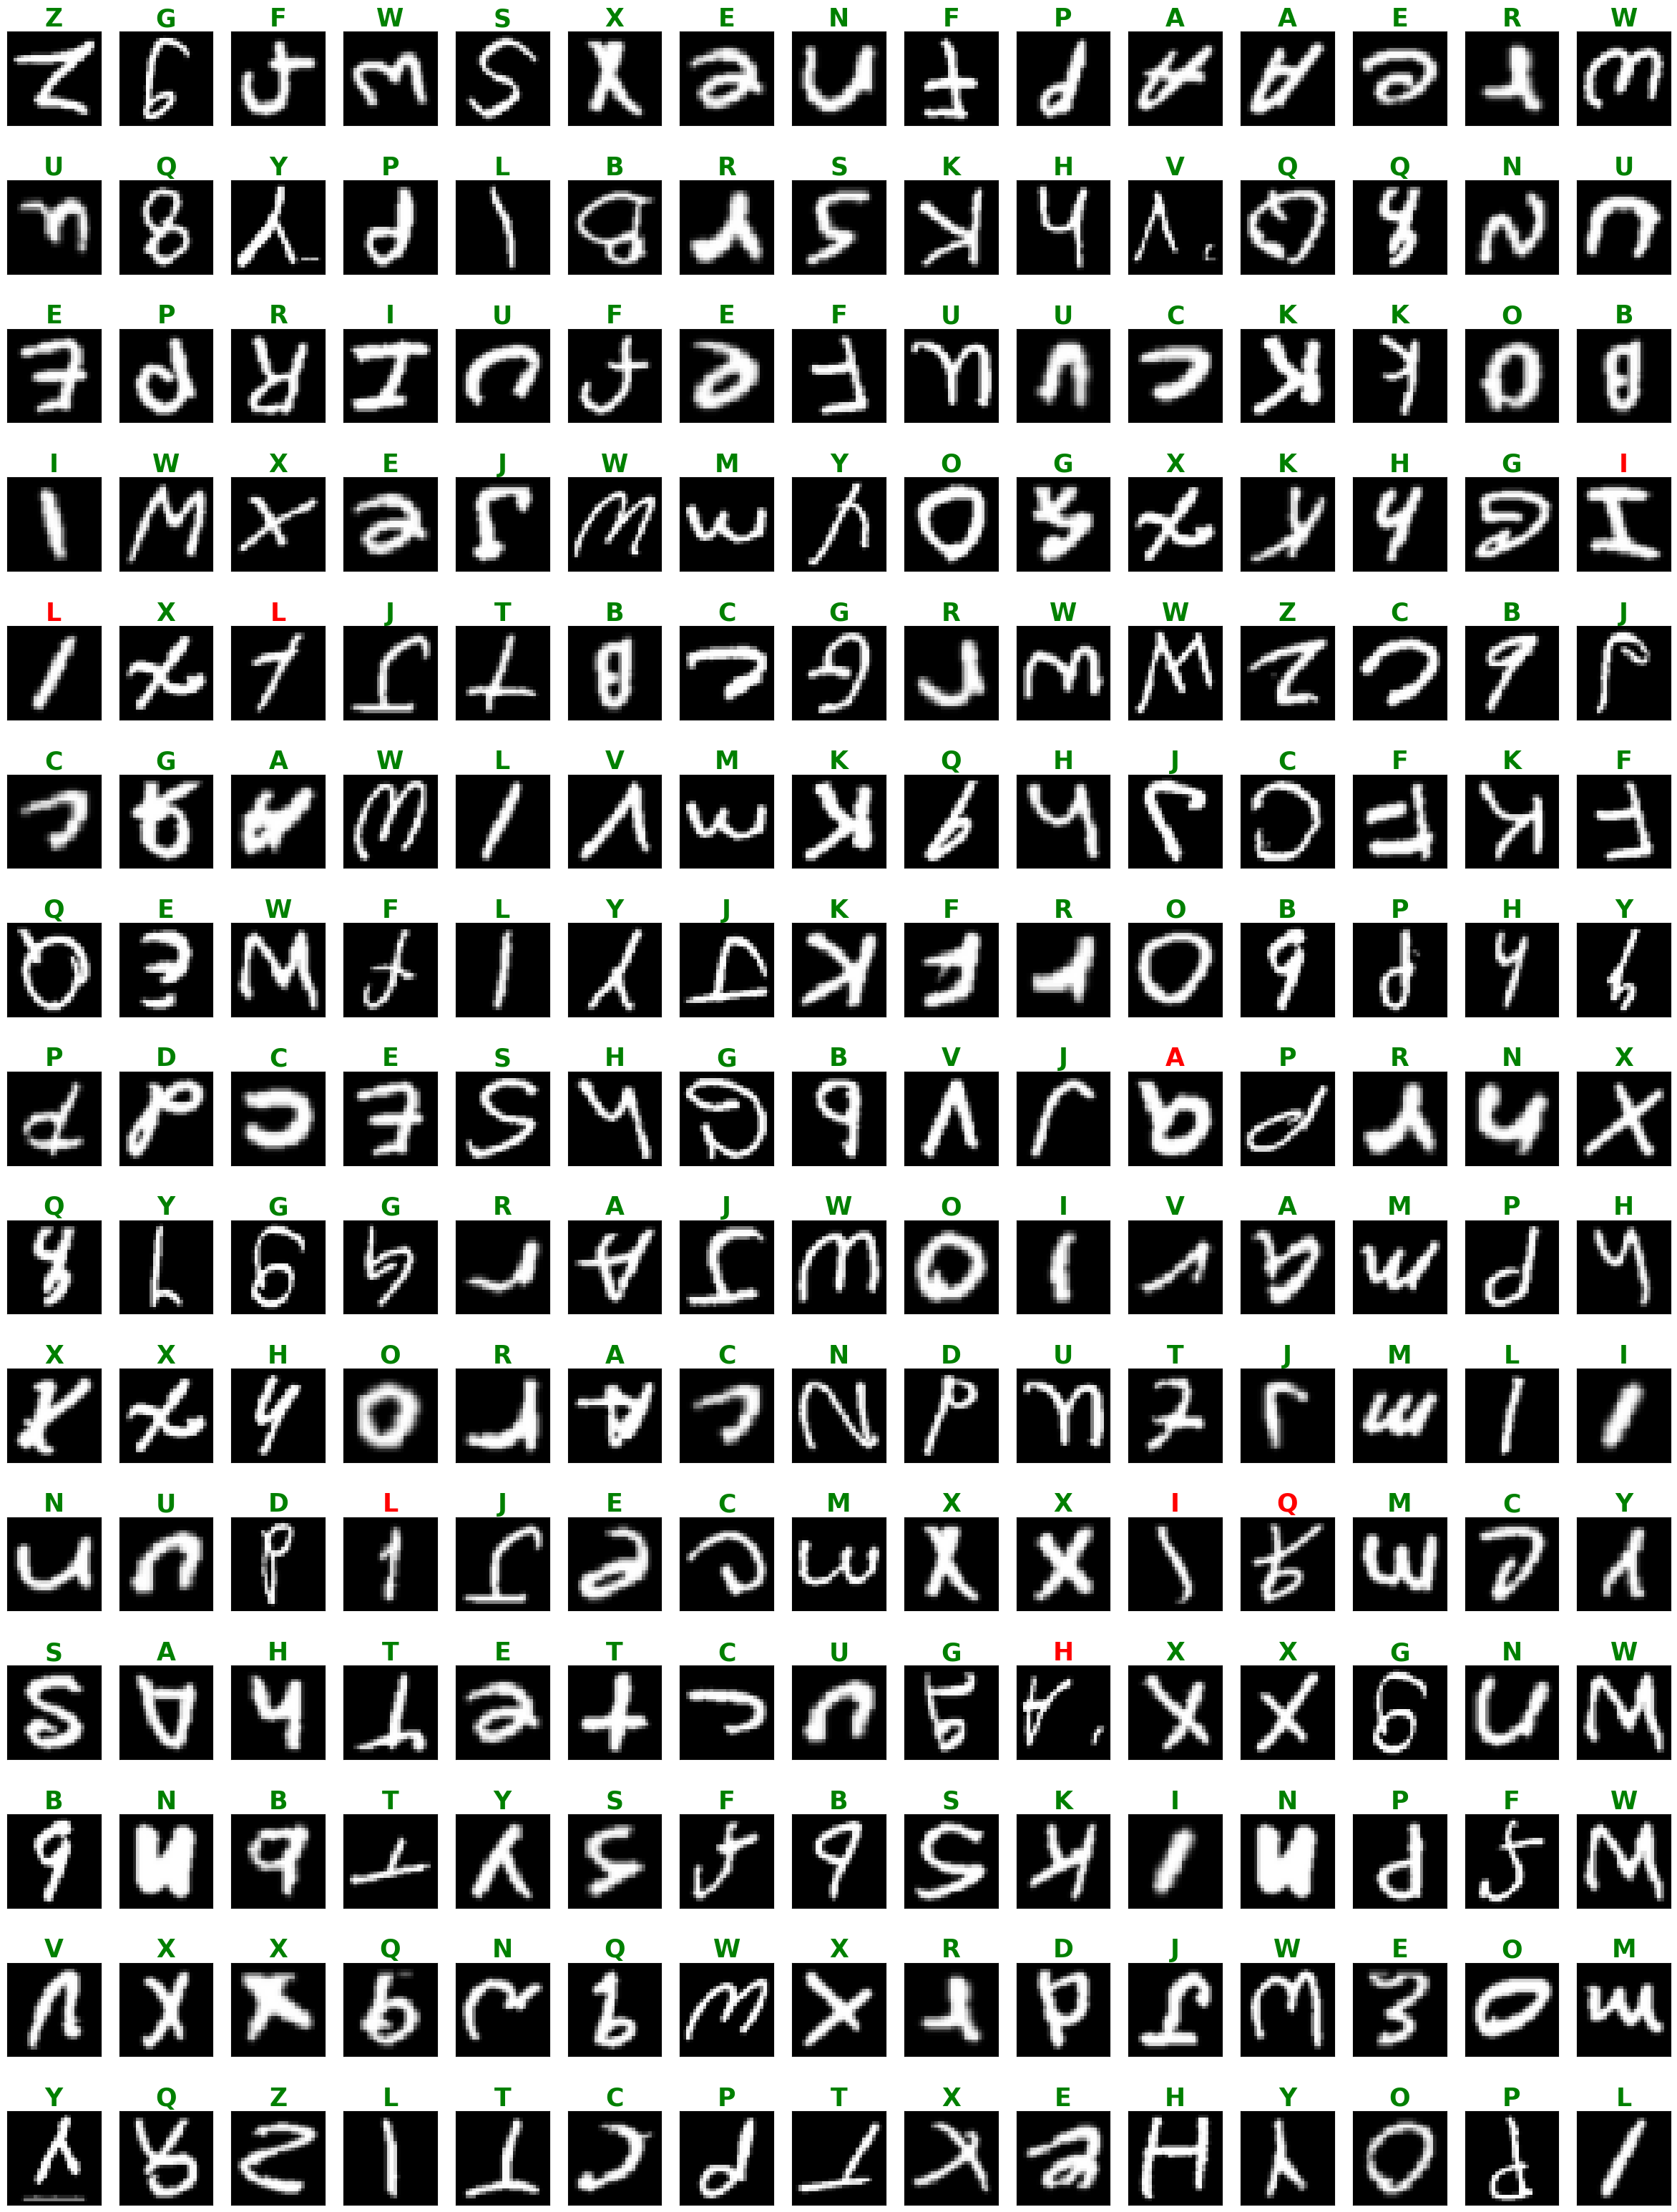

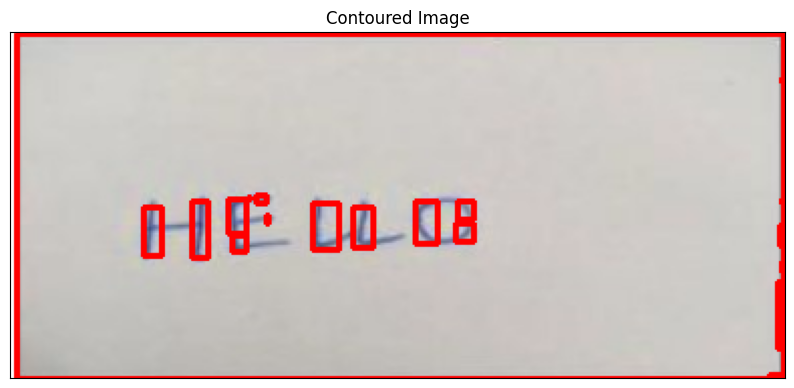

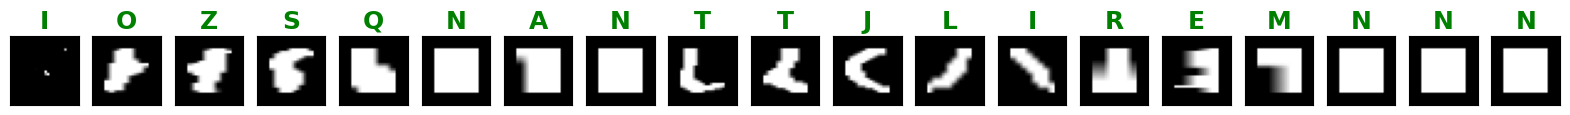

The Recognized Alphabets are : I O Z S Q N A N T T J L I R E M N N N


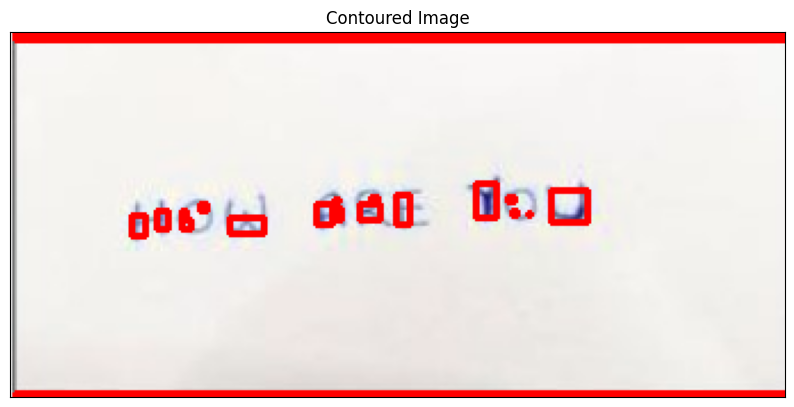

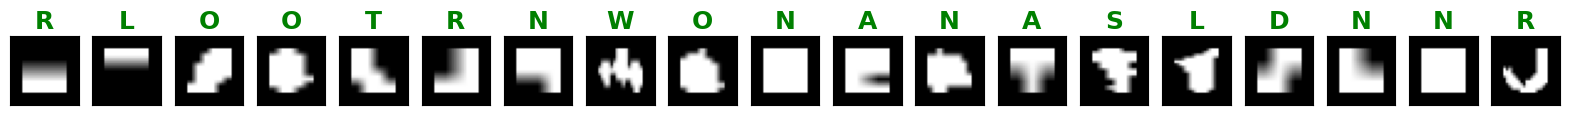

The Recognized Alphabets are : R L O O T R N W O N A N A S L D N N R


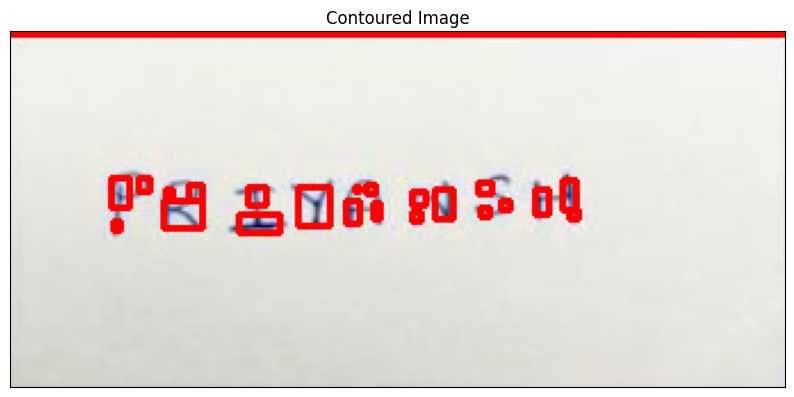

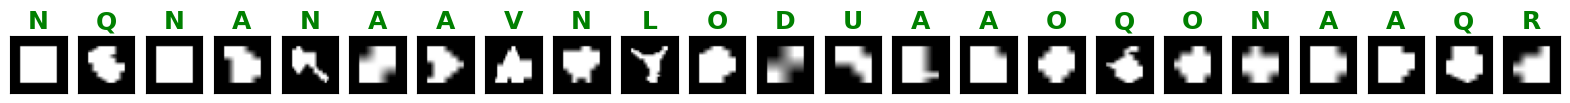

The Recognized Alphabets are : N Q N A N A A V N L O D U A A O Q O N A A Q R


In [2]:
# Code Example 4: Handwritten Alphabet Recognition
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import BatchNormalization
from keras.optimizers import SGD

train_df = pd.read_csv('D:/EMNIST/emnist-letters-train.csv')
test_df = pd.read_csv('D:/EMNIST/emnist-letters-test.csv')

df = pd.concat([train_df, test_df], ignore_index=True)

data_array = np.array(df, dtype=np.uint8)

del df

print(data_array.shape)

alpha = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

labels = data_array[:, 0]

valid_idx = labels > 0

labels = labels[valid_idx] - 1

x = data_array[:, 1:785]

x = x[valid_idx]

x = x.reshape(-1, 28, 28)

x = np.array([np.fliplr(np.rot90(img)) for img in x])

x = x / 255.0

del data_array

unique, counts = np.unique(labels, return_counts=True)

print(unique)
print(counts)

fig = plt.figure(figsize=(15,6))

plt.xlabel('ALPHABETS', fontsize=14)
plt.ylabel('COUNT', fontsize=14)

plt.bar(alpha, counts)

plt.show()

a = np.random.randint(
    low=0,
    high=x.shape[0],
    size=400
)

fig = plt.figure(figsize=(30,30))

c = 1

for i in a:

    fig.add_subplot(20,20,c)

    plt.xticks([])
    plt.yticks([])

    plt.imshow(x[i], cmap='gray')

    c += 1

plt.show()

x = x.reshape(x.shape[0], 28, 28, 1)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    labels,
    test_size=0.01,
    random_state=42
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

model = Sequential([

    Conv2D(
        128,
        (3,3),
        activation='relu',
        kernel_initializer='he_uniform',
        input_shape=(28,28,1),
        padding='same'
    ),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        kernel_initializer='he_uniform',
        padding='same'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        kernel_initializer='he_uniform',
        padding='same'
    ),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        kernel_initializer='he_uniform',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        100,
        activation='relu',
        kernel_initializer='he_uniform'
    ),

    Dropout(0.1),

    Dense(
        64,
        activation='relu',
        kernel_initializer='he_uniform'
    ),

    Dropout(0.125),

    BatchNormalization(),

    Dense(
        26,
        activation='softmax'
    )
])

optimizer = SGD(
    learning_rate=0.01,
    momentum=0.9
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=150,
    validation_data=(x_test, y_test)
)

val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
accuracy = history.history['accuracy']

fig = plt.figure(figsize=(10,15))

fig.add_subplot(2,1,1)

plt.title('Cross Entropy Loss')

plt.plot(loss, color='blue', label='train')
plt.plot(val_loss, color='red', label='test')

plt.legend()

fig.add_subplot(2,1,2)

plt.title('Classification Accuracy')

plt.plot(accuracy, color='blue', label='train')
plt.plot(val_accuracy, color='red', label='test')

plt.legend()

plt.show()

metrics = model.evaluate(x_test, y_test)

print("Test Accuracy is : {:.2f}".format(metrics[1] * 100))
print("Test Loss is : {:.2f}".format(metrics[0]))

model.save('Alphabet_Recognition.h5')

model = tf.keras.models.load_model('Alphabet_Recognition.h5')

metrics = model.evaluate(x_test, y_test)

print(metrics)

print("Test Accuracy is : {:.2f}".format(metrics[1] * 100))
print("Test Loss is : {:.2f}".format(metrics[0]))

def test_images(n=225):

    index = np.random.randint(
        low=0,
        high=x_test.shape[0],
        size=n
    )

    fig = plt.figure(figsize=(30,40))

    for i in range(n):

        prediction = model.predict(
            x_test[index[i]].reshape(1,28,28,1),
            verbose=0
        )

        pred = np.argmax(prediction)

        actual = y_test[index[i]]

        fig.add_subplot(15,15,i+1)

        plt.xticks([])
        plt.yticks([])

        if actual == pred:

            plt.title(
                alpha[pred],
                color='green',
                fontsize=25,
                fontweight='bold'
            )

        else:

            plt.title(
                alpha[pred],
                color='red',
                fontsize=25,
                fontweight='bold'
            )

        plt.imshow(
            x_test[index[i]].reshape(28,28),
            cmap='gray'
        )

    plt.show()

test_images()

def alphabet_recognize(filepath):

    image = cv2.imread(filepath)

    if image is None:
        print("Image not found")
        return

    blur_image = cv2.medianBlur(image, 7)

    grey = cv2.cvtColor(
        blur_image,
        cv2.COLOR_BGR2GRAY
    )

    thresh = cv2.adaptiveThreshold(
        grey,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        41,
        15
    )

    contours, hierarchy = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        print("No alphabets detected")
        return

    preprocessed_digits = []

    boundingBoxes = [cv2.boundingRect(c) for c in contours]

    contours, boundingBoxes = zip(
        *sorted(
            zip(contours, boundingBoxes),
            key=lambda b: b[1][0],
            reverse=False
        )
    )

    for c in contours:

        x1, y1, w, h = cv2.boundingRect(c)

        cv2.rectangle(
            image,
            (x1, y1),
            (x1 + w, y1 + h),
            (255, 0, 0),
            2
        )

        digit = thresh[y1:y1+h, x1:x1+w]

        resized_digit = cv2.resize(
            digit,
            (18,18)
        )

        padded_digit = np.pad(
            resized_digit,
            ((5,5),(5,5)),
            "constant",
            constant_values=0
        )

        preprocessed_digits.append(padded_digit)

    plt.figure(figsize=(10,10))

    plt.xticks([])
    plt.yticks([])

    plt.title("Contoured Image")

    plt.imshow(image)

    plt.show()

    fig = plt.figure(figsize=(20,4))

    alphabets = []

    for i, digit in enumerate(preprocessed_digits):

        prediction = model.predict(
            digit.reshape(1,28,28,1) / 255.0,
            verbose=0
        )

        pred = alpha[np.argmax(prediction)]

        alphabets.append(pred)

        fig.add_subplot(1, len(preprocessed_digits), i+1)

        plt.xticks([])
        plt.yticks([])

        plt.imshow(
            digit.reshape(28,28),
            cmap='gray'
        )

        plt.title(
            pred,
            color='green',
            fontsize=18,
            fontweight='bold'
        )

    plt.show()

    print("The Recognized Alphabets are :", *alphabets)

alphabet_recognize('D:/EMNIST/1.jpg')

alphabet_recognize('D:/EMNIST/2.jpg')

alphabet_recognize('D:/EMNIST/3.jpg')

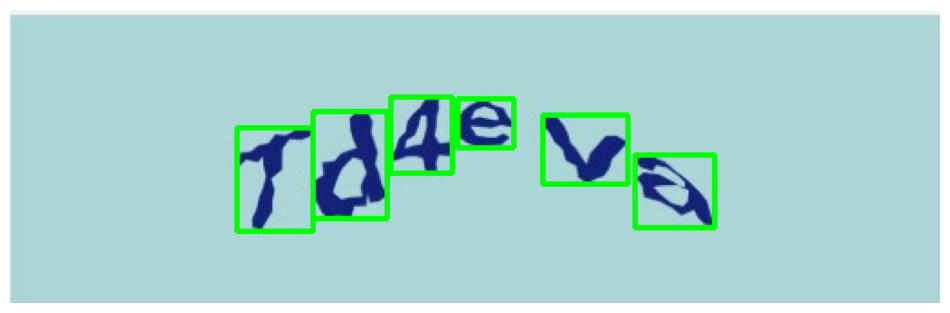

Predicted CAPTCHA: QPYANQ


In [3]:
# Case Study 1: CAPTCHA Recognition for Automated Bot Detection
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('Alphabet_Recognition.h5')

alpha = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def preprocess_char(img):
    img = cv2.resize(img, (28, 28))
    img = img.astype("float32") / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img

def captcha_recognize(filepath):
    image = cv2.imread(filepath)

    if image is None:
        print("Image not found!")
        return

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    result = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        if w < 8 or h < 8:
            continue

        char_img = thresh[y:y+h, x:x+w]

        processed = preprocess_char(char_img)

        prediction = model.predict(processed, verbose=0)
        pred = alpha[np.argmax(prediction)]

        result.append(pred)

        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

    result_text = ''.join(result)

    plt.figure(figsize=(12, 4))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    print("Predicted CAPTCHA:", result_text)


captcha_recognize("D:/EMNIST/Captcha.jpg")

In [5]:
# Case Study 2: License Plate Readers in Traffic Management
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('Alphabet_Recognition.h5')
alpha_num = list('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def preprocess_char(char_img):
    char = cv2.resize(char_img, (28, 28))
    char = char.astype("float32") / 255.0
    char = char.reshape(1, 28, 28, 1)
    return char

def license_plate_reader(filepath):
    image = cv2.imread(filepath)

    if image is None:
        print("Image not found!")
        return

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(blur, 30, 200)

    contours, _ = cv2.findContours(
        edged, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    plate = None

    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(c)
            plate = image[y:y+h, x:x+w]
            break

    if plate is None:
        print("License plate not detected!")
        return

    gray_plate = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(
        gray_plate, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    plate_text = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        if h > 15 and w > 5:
            char_img = thresh[y:y+h, x:x+w]

            processed = preprocess_char(char_img)

            prediction = model.predict(processed, verbose=0)
            pred = alpha_num[np.argmax(prediction)]

            plate_text.append(pred)

    result = ''.join(plate_text)

    plt.figure(figsize=(8,3))
    plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    print("License Plate:", result)


license_plate_reader("D:/EMNIST/Plate.jpg")

License plate not detected!


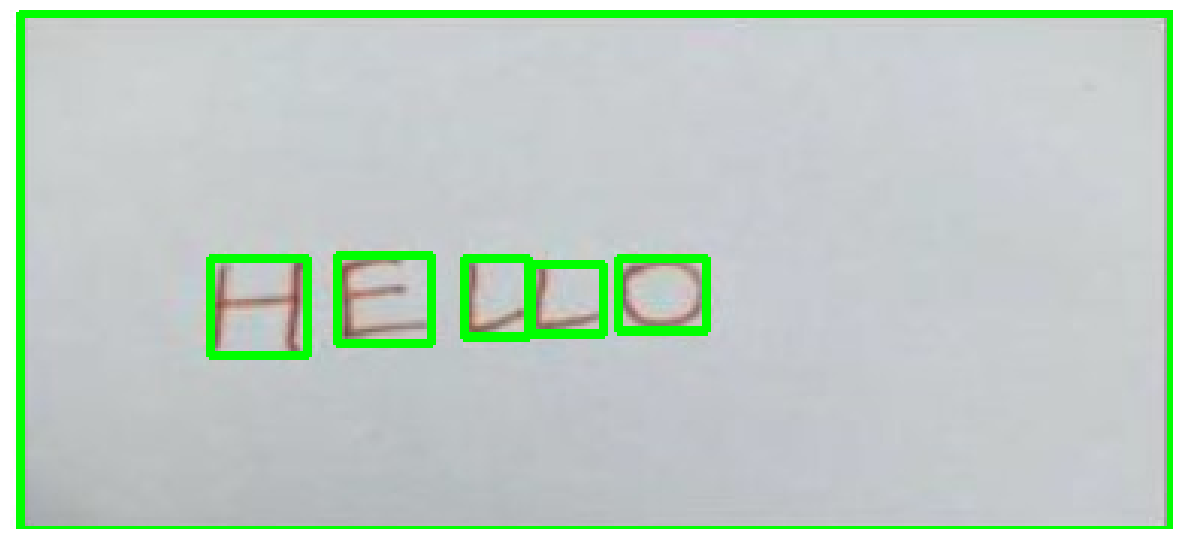

Detected Address Text:
FHONOO


In [6]:
# Case Study 3: Multilingual Handwritten Alphabet Recognition for Postal Automation
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('Alphabet_Recognition.h5')

alpha = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def postal_address_recognition(filepath):

    image = cv2.imread(filepath)

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    thresh = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        41,
        15
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(
        contours,
        key=lambda c: cv2.boundingRect(c)[0]
    )

    address_text = []

    for c in contours:

        x, y, w, h = cv2.boundingRect(c)

        if w > 5 and h > 10:

            char = thresh[y:y+h, x:x+w]

            char = cv2.resize(char, (18,18))

            char = np.pad(
                char,
                ((5,5),(5,5)),
                mode='constant'
            )

            prediction = model.predict(
                char.reshape(1,28,28,1)/255.0,
                verbose=0
            )

            pred = alpha[np.argmax(prediction)]

            address_text.append(pred)

            cv2.rectangle(
                image,
                (x,y),
                (x+w,y+h),
                (0,255,0),
                2
            )

    plt.figure(figsize=(15,8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    print("Detected Address Text:")
    print("".join(address_text))

postal_address_recognition("D:/EMNIST/1.jpg")

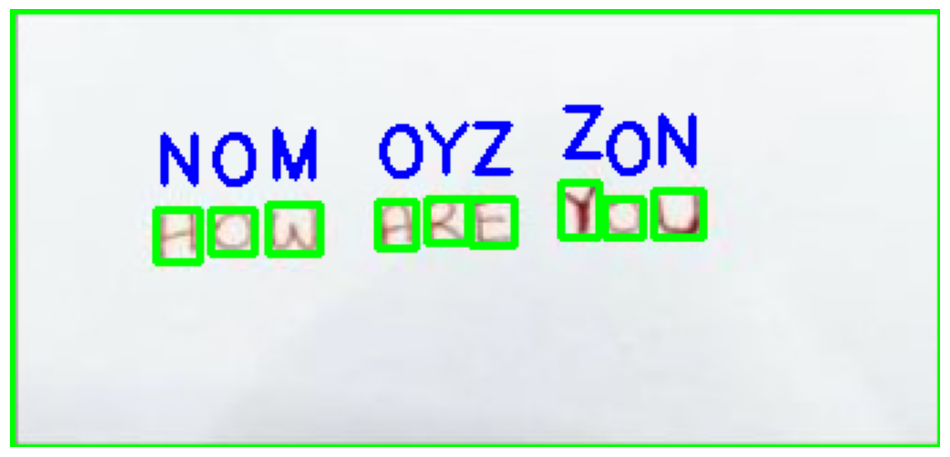

Recognized Text:
FNOMOYZZON


In [7]:
# Case Study 4: Real-Time Handwritten Input Recognition for Smart Devices
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('Alphabet_Recognition.h5')

alpha = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def smart_device_handwriting(filepath):

    image = cv2.imread(filepath)

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    blur = cv2.GaussianBlur(
        gray,
        (3,3),
        0
    )

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        41,
        15
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(
        contours,
        key=lambda c: cv2.boundingRect(c)[0]
    )

    recognized_text = []

    for c in contours:

        x, y, w, h = cv2.boundingRect(c)

        if w > 5 and h > 10:

            char = thresh[y:y+h, x:x+w]

            char = cv2.resize(
                char,
                (18,18)
            )

            char = np.pad(
                char,
                ((5,5),(5,5)),
                mode='constant'
            )

            prediction = model.predict(
                char.reshape(1,28,28,1)/255.0,
                verbose=0
            )

            pred = alpha[np.argmax(prediction)]

            recognized_text.append(pred)

            cv2.rectangle(
                image,
                (x,y),
                (x+w,y+h),
                (0,255,0),
                2
            )

            cv2.putText(
                image,
                pred,
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,0,0),
                2
            )

    plt.figure(figsize=(12,6))

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis('off')

    plt.show()

    print("Recognized Text:")
    print("".join(recognized_text))

smart_device_handwriting("D:/EMNIST/2.jpg")

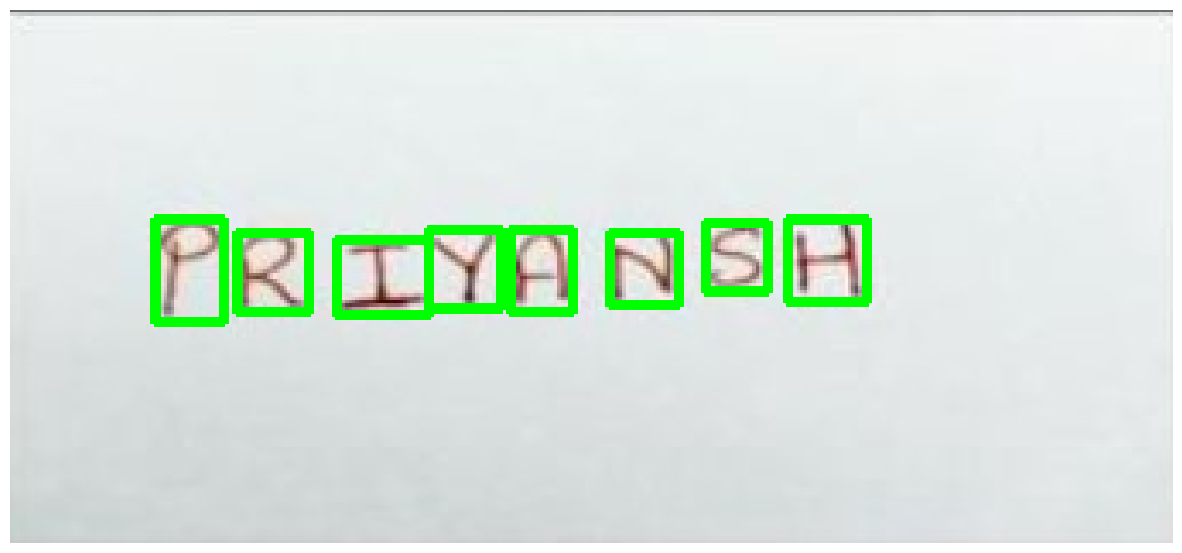

Transcribed Manuscript:
DXIHBNSM


In [8]:
# Case Study 5: Historical Manuscript Digitization
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('Alphabet_Recognition.h5')

alpha = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def manuscript_transcription(filepath):

    image = cv2.imread(filepath)

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    enhanced = cv2.equalizeHist(gray)

    blur = cv2.GaussianBlur(
        enhanced,
        (5,5),
        0
    )

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        41,
        15
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(
        contours,
        key=lambda c: cv2.boundingRect(c)[0]
    )

    manuscript_text = []

    for c in contours:

        x, y, w, h = cv2.boundingRect(c)

        if w > 5 and h > 10:

            char = thresh[y:y+h, x:x+w]

            char = cv2.resize(char, (18,18))

            char = np.pad(
                char,
                ((5,5),(5,5)),
                mode='constant'
            )

            prediction = model.predict(
                char.reshape(1,28,28,1)/255.0,
                verbose=0
            )

            pred = alpha[np.argmax(prediction)]

            manuscript_text.append(pred)

            cv2.rectangle(
                image,
                (x,y),
                (x+w,y+h),
                (0,255,0),
                2
            )

    plt.figure(figsize=(15,8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    print("Transcribed Manuscript:")
    print("".join(manuscript_text))

manuscript_transcription("D:/EMNIST/3.jpg")